# Willingness-to-Pay Estimation and Bundle Pricing Decisions

## Scenario
A pricing team needs to know how much customers would pay for specific meal kit
features. Using part-worth utilities from the choice model, compute directional
WTP estimates and score candidate plans to recommend a launch configuration.

## Data: `mealkit_choice_tasks.csv` and `mealkit_plans.csv`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

CHOICE_PATH = DATA_DIR / 'mealkit_choice_tasks.csv'
PLANS_PATH  = DATA_DIR / 'mealkit_plans.csv'
ADOPT_PATH  = DATA_DIR / 'mealkit_trial_adoption.csv'
SURVEY_PATH = DATA_DIR / 'mealkit_survey.csv'
MMM_PATH    = DATA_DIR / 'mealkit_marketing_weekly.csv'
from sklearn.linear_model import LogisticRegression
df = pd.read_csv(CHOICE_PATH)
plans = pd.read_csv(PLANS_PATH)
print("Plans available:")
print(plans)

Plans available:
          plan  price_per_week  meals_per_week cuisine_variety  \
0    QuickBite              35               2        standard   
1      Classic              55               4        standard   
2      Premium              85               4         premium   
3  FamilyFeast              95               6        standard   

  dietary_options live_cooking_class  servings  
0              no                 no         2  
1             yes                 no         2  
2             yes                yes         2  
3             yes                 no         4  


## Step 1: Fit Conjoint Model

In [3]:
df_enc = pd.get_dummies(df,
    columns=['cuisine_variety','dietary_options','live_cooking_class'],
    drop_first=False)
df_enc = df_enc.drop(columns=[
    'cuisine_variety_standard','dietary_options_no','live_cooking_class_no'])
feat_cols = ['price_per_week','meals_per_week','servings',
             'cuisine_variety_premium','dietary_options_yes','live_cooking_class_yes']
X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)
partworths = pd.Series(model.coef_[0], index=feat_cols)
beta_price = partworths['price_per_week']   # negative
print(f"beta_price = {beta_price:.4f}")

beta_price = -0.0352


## Step 2: Compute WTP

In [4]:
# WTP = -beta_feature / beta_price
# Sign flip accounts for the negative price coefficient
wtp_dietary  = -partworths['dietary_options_yes']    / beta_price
wtp_class    = -partworths['live_cooking_class_yes'] / beta_price
wtp_cuisine  = -partworths['cuisine_variety_premium'] / beta_price

print(f"WTP for Dietary Options:    ${wtp_dietary:.2f}/week")
print(f"WTP for Live Cooking Class: ${wtp_class:.2f}/week")
print(f"WTP for Premium Cuisine:    ${wtp_cuisine:.2f}/week")
print()
print("Note: These are directional estimates from stated-preference survey data.")
print("Use as pricing anchors within the tested range ($30–$110/week).")

WTP for Dietary Options:    $19.29/week
WTP for Live Cooking Class: $11.13/week
WTP for Premium Cuisine:    $10.18/week

Note: These are directional estimates from stated-preference survey data.
Use as pricing anchors within the tested range ($30–$110/week).


## Step 3: Score Candidate Plans

In [5]:
p = plans.copy()
p['cuisine_variety_premium']  = (p['cuisine_variety']    == 'premium').astype(int)
p['dietary_options_yes']      = (p['dietary_options']    == 'yes').astype(int)
p['live_cooking_class_yes']   = (p['live_cooking_class'] == 'yes').astype(int)

X_plans = p[feat_cols].astype(float)
p['score'] = model.predict_proba(X_plans)[:, 1]
ranked = p[['plan','price_per_week','score']].sort_values('score', ascending=False)
print("Bundle scores (predicted choice probability):")
print(ranked.to_string(index=False))

Bundle scores (predicted choice probability):
       plan  price_per_week    score
    Classic              55 0.373162
  QuickBite              35 0.346412
    Premium              85 0.304853
FamilyFeast              95 0.160510


## Step 4: Bundle Score Bar Chart

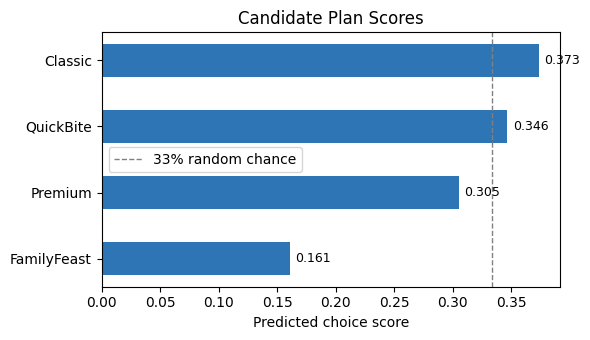

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ranked_plot = p.sort_values('score')
ax.barh(ranked_plot['plan'], ranked_plot['score'], color='#2E75B6', height=0.5)
ax.set_xlabel('Predicted choice score'); ax.set_title('Candidate Plan Scores')
ax.axvline(0.333, color='gray', linestyle='--', linewidth=1, label='33% random chance')
ax.legend()
for bar, v in zip(ax.patches, ranked_plot['score']):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Recommendation

**Recommended launch plan: Classic at $55/week**

**WTP rationale:** Customers show a WTP of approximately $19.29/week for dietary
options. Classic includes dietary accommodation at $55/week — a $20 premium over
QuickBite ($35). This is within the modeled WTP, suggesting most customers would
find this price point reasonable for the feature upgrade.

**Score rationale:** Classic achieves the highest predicted choice probability (0.373),
outperforming Premium (0.305) despite fewer premium features. Premium's $85 price
point suppresses its score — the price coefficient erodes the utility gains from
live class and premium cuisine.

**Assumptions and Limitations:**
- WTP estimates come from stated-preference survey data, not revealed willingness-to-pay
  in a real purchase context. Real-world price sensitivity may differ.
- The additivity assumption means interactions between features (e.g., live class
  AND premium cuisine) are not modeled.
- WTP estimates are only valid within the tested price range ($30–$110/week).
